# RQ3 (Portfolio Examination)

## Short Memory, Long Text -- How Sequence Length Reveals Architecture Limits
#### *Comparing TextCNN, Vanilla RNN, and LSTM across Sequence Lengths*

**Due Date:** May 7, 2026
**Team:** NW2
**Members:** Nils Wagner, Nick Wenzel

---

### Research Question

> *How do TextCNN, vanilla RNN, and LSTM differ in their ability to model short-range vs. long-range dependencies in text, and what role does sequence length play?*

### What This Notebook Does

This template provides:
1. A text data pipeline with **configurable sequence length**
2. Three model architectures: TextCNN, Vanilla RNN, LSTM (all working out of the box)
3. A training loop and evaluation function
4. A framework to run all experiments systematically
5. Plotting helpers for the key visualizations

**Your job:** Run the experiments, analyze the results, and write the report.

Look for `# TODO` comments — these mark where you need to add your analysis.

In [1]:
# ── Setup ─────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re
import time

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup complete.")

Using device: cuda
Setup complete.


---
## Part 1: Data Pipeline with Variable Sequence Length

The key variable in this experiment is **max_seq_len**. We truncate/pad all texts to this length. By varying it (32, 64, 128, 256, 512), we test how each architecture handles different amounts of context.

In [2]:
# ── Text pipeline ─────────────────────────────────────────────

def tokenize(text):
    """Simple whitespace + punctuation tokenizer."""
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

def build_vocab(texts, max_vocab=20000, min_freq=2):
    """Build vocabulary from tokenized texts."""
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, count in counter.most_common(max_vocab - 2):
        if count >= min_freq:
            vocab[word] = len(vocab)
    return vocab

def encode(text, vocab, max_len):
    """Tokenize, encode, and pad/truncate to fixed length."""
    tokens = tokenize(text)[:max_len]  # truncate
    ids = [vocab.get(t, vocab['<UNK>']) for t in tokens]
    ids = ids + [0] * (max_len - len(ids))  # pad
    return ids

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.encodings = [encode(t, vocab, max_len) for t in texts]
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return (torch.tensor(self.encodings[idx], dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.long))

print("Text pipeline defined.")

Text pipeline defined.


In [3]:
# ── Load IMDB dataset ──────────────────────────────────────────
# IMDB Large Movie Review Dataset (Maas et al., 2011)
# - 25,000 training + 25,000 test reviews (balanced positive/negative)
# - Average review length: ~230 words
# - Binary sentiment classification
# Reference: https://ai.stanford.edu/~amaas/data/sentiment/

from datasets import load_dataset

print("Loading IMDB dataset...")
raw = load_dataset("imdb")
train_texts = raw['train']['text']
train_labels = raw['train']['label']
test_texts = raw['test']['text']
test_labels = raw['test']['label']

print(f"Train: {len(train_texts):,} reviews")
print(f"Test:  {len(test_texts):,} reviews")

# Show review length distribution
lengths = [len(tokenize(t)) for t in train_texts]
print(f"\nReview length statistics (in tokens):")
print(f"  Mean:   {np.mean(lengths):.0f}")
print(f"  Median: {np.median(lengths):.0f}")
print(f"  Min:    {np.min(lengths)}")
print(f"  Max:    {np.max(lengths)}")

# What fraction of reviews is fully contained at each sequence length?
for sl in [32, 64, 128, 256, 512]:
    frac = np.mean(np.array(lengths) <= sl)
    print(f"  Fully contained at seq_len={sl:3d}: {frac:.1%}")

# Build vocabulary (once, shared across ALL experiments)
vocab = build_vocab(train_texts, max_vocab=20000, min_freq=2)
print(f"\nVocabulary size: {len(vocab):,}")

Loading IMDB dataset...


Train: 25,000 reviews
Test:  25,000 reviews

Review length statistics (in tokens):
  Mean:   238
  Median: 178
  Min:    10
  Max:    2505
  Fully contained at seq_len= 32: 0.3%
  Fully contained at seq_len= 64: 4.8%
  Fully contained at seq_len=128: 24.1%
  Fully contained at seq_len=256: 70.0%
  Fully contained at seq_len=512: 92.1%

Vocabulary size: 20,000


In [4]:
# ── Helper: create dataloaders for a specific sequence length ─
BATCH_SIZE = 64

def make_loaders(max_len):
    """Create train/test DataLoaders for a given max sequence length."""
    train_ds = SentimentDataset(train_texts, train_labels, vocab, max_len)
    test_ds = SentimentDataset(test_texts, test_labels, vocab, max_len)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)
    return train_loader, test_loader

# Test it
loader_test, _ = make_loaders(128)
bx, by = next(iter(loader_test))
print(f"Batch with max_len=128: input {bx.shape}, labels {by.shape}")

Batch with max_len=128: input torch.Size([64, 128]), labels torch.Size([64])


---
## Part 2: Model Definitions

Three architectures, all with the same embedding and output dimensions for a fair comparison.

In [5]:
# ── Shared hyperparameters ─────────────────────────────────────
EMBED_DIM = 100
HIDDEN_DIM = 128
NUM_CLASSES = 2
DROPOUT = 0.5
NUM_FILTERS = 100
FILTER_SIZES = (3, 4, 5)

In [6]:
# ── Model 1: TextCNN ──────────────────────────────────────────

class TextCNN(nn.Module):
    """TextCNN (Kim 2014) with multiple filter sizes."""
    def __init__(self, vocab_size, embed_dim, num_classes,
                 num_filters=100, filter_sizes=(3, 4, 5), dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x).transpose(1, 2)  # (B, D, L)
        conv_outs = [F.relu(conv(x)).max(dim=2).values for conv in self.convs]
        x = torch.cat(conv_outs, dim=1)
        return self.fc(self.dropout(x))

print("TextCNN defined.")

TextCNN defined.


In [7]:
# ── Model 2: Vanilla RNN ──────────────────────────────────────

class VanillaRNNClassifier(nn.Module):
    """Vanilla RNN (no gating) for text classification."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)            # (B, L, D)
        _, h_n = self.rnn(x)             # h_n: (1, B, H)
        h = h_n.squeeze(0)               # (B, H)
        return self.fc(self.dropout(h))

print("VanillaRNNClassifier defined.")

VanillaRNNClassifier defined.


In [8]:
# ── Model 3: LSTM ─────────────────────────────────────────────

class LSTMClassifier(nn.Module):
    """LSTM with gated memory for text classification."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)            # (B, L, D)
        _, (h_n, c_n) = self.lstm(x)     # h_n: (1, B, H)
        h = h_n.squeeze(0)               # (B, H)
        return self.fc(self.dropout(h))

print("LSTMClassifier defined.")

LSTMClassifier defined.


In [9]:
# ── (Optional) Model 4: MLP Baseline ──────────────────────────

class MLPBaseline(nn.Module):
    """MLP with mean-pooled embeddings (Week 3 architecture)."""
    def __init__(self, vocab_size, embed_dim, num_classes, hidden_dim=256, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        emb = self.embedding(x)
        mask = (x != 0).float().unsqueeze(2)
        emb = emb * mask
        lengths = mask.sum(dim=1).clamp(min=1)
        pooled = emb.sum(dim=1) / lengths
        return self.fc2(self.dropout(F.relu(self.fc1(pooled))))

# Uncomment to include MLP in the comparison:
# print("MLPBaseline defined.")

---
## Part 3: Training and Evaluation Framework

A single function that trains a model and returns test accuracy, F1, and training time.

In [10]:
# ── Training function ─────────────────────────────────────────
from sklearn.metrics import f1_score

def train_and_evaluate(model, train_loader, test_loader, epochs=10, lr=1e-3):
    """Train a model and return test accuracy, F1, and time per epoch."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    epoch_times = []

    for epoch in range(epochs):
        # Training
        model.train()
        t0 = time.time()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
        epoch_times.append(time.time() - t0)

    # Evaluation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for bx, by in test_loader:
            bx = bx.to(device)
            preds = model(bx).argmax(dim=1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(by.tolist())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    f1 = f1_score(all_labels, all_preds, average='macro')
    avg_time = np.mean(epoch_times)

    return {
        'accuracy': accuracy,
        'f1': f1,
        'time_per_epoch': avg_time,
        'predictions': all_preds,
        'labels': all_labels,
    }

print("Training framework ready.")

Training framework ready.


---
## Part 4: Run All Experiments

This is the core experiment loop. For each sequence length × each architecture, we train a model and record results.

In [11]:
# ── Experiment configuration ───────────────────────────────────
SEQ_LENGTHS = [32, 64, 128, 256, 512]
NUM_EPOCHS = 10

# Models to compare (add MLPBaseline if desired)
def get_models():
    return {
        'TextCNN': TextCNN(len(vocab), EMBED_DIM, NUM_CLASSES,
                           NUM_FILTERS, FILTER_SIZES, DROPOUT),
        'Vanilla RNN': VanillaRNNClassifier(len(vocab), EMBED_DIM,
                                             HIDDEN_DIM, NUM_CLASSES, DROPOUT),
        'LSTM': LSTMClassifier(len(vocab), EMBED_DIM,
                                HIDDEN_DIM, NUM_CLASSES, DROPOUT),
        # Uncomment to add MLP:
        # 'MLP': MLPBaseline(len(vocab), EMBED_DIM, NUM_CLASSES),
    }

print(f"Experiment plan: {len(get_models())} models × {len(SEQ_LENGTHS)} sequence lengths")
print(f"  Models: {list(get_models().keys())}")
print(f"  Seq lengths: {SEQ_LENGTHS}")
print(f"  Epochs per run: {NUM_EPOCHS}")
print(f"  Total training runs: {len(get_models()) * len(SEQ_LENGTHS)}")

Experiment plan: 3 models × 5 sequence lengths
  Models: ['TextCNN', 'Vanilla RNN', 'LSTM']
  Seq lengths: [32, 64, 128, 256, 512]
  Epochs per run: 10
  Total training runs: 15


In [12]:
# ── Run all experiments ────────────────────────────────────────
# WARNING: This takes a while! ~15 runs × 10 epochs each.
# On CPU: expect 30-60 min total. On GPU: ~10-15 min.

results = {}

for seq_len in SEQ_LENGTHS:
    print(f"\n{'='*60}")
    print(f"Sequence Length: {seq_len}")
    print(f"{'='*60}")

    train_loader, test_loader = make_loaders(seq_len)

    for model_name, model in get_models().items():
        print(f"  Training {model_name}...", end=" ", flush=True)

        torch.manual_seed(42)  # same init for fair comparison
        result = train_and_evaluate(model, train_loader, test_loader,
                                     epochs=NUM_EPOCHS)

        key = (model_name, seq_len)
        results[key] = result

        print(f"Acc: {result['accuracy']:.4f}  "
              f"F1: {result['f1']:.4f}  "
              f"Time: {result['time_per_epoch']:.1f}s/epoch")

print("\nAll experiments complete!")


Sequence Length: 32
  Training TextCNN... Acc: 0.7009  F1: 0.7009  Time: 3.1s/epoch
  Training Vanilla RNN... Acc: 0.6848  F1: 0.6848  Time: 2.8s/epoch
  Training LSTM... Acc: 0.7054  F1: 0.7043  Time: 2.8s/epoch

Sequence Length: 64
  Training TextCNN... Acc: 0.7483  F1: 0.7481  Time: 3.0s/epoch
  Training Vanilla RNN... Acc: 0.7027  F1: 0.7024  Time: 2.9s/epoch
  Training LSTM... Acc: 0.7451  F1: 0.7451  Time: 2.9s/epoch

Sequence Length: 128
  Training TextCNN... Acc: 0.8057  F1: 0.8057  Time: 3.0s/epoch
  Training Vanilla RNN... Acc: 0.7036  F1: 0.7026  Time: 3.0s/epoch
  Training LSTM... Acc: 0.8052  F1: 0.8052  Time: 2.9s/epoch

Sequence Length: 256
  Training TextCNN... Acc: 0.8506  F1: 0.8506  Time: 3.2s/epoch
  Training Vanilla RNN... Acc: 0.5000  F1: 0.5000  Time: 3.0s/epoch
  Training LSTM... Acc: 0.6990  F1: 0.6973  Time: 3.0s/epoch

Sequence Length: 512
  Training TextCNN... Acc: 0.8710  F1: 0.8710  Time: 3.4s/epoch
  Training Vanilla RNN... Acc: 0.5071  F1: 0.4358  Time:

---
## Part 5: Results Visualization

### 5.1 Performance Over Sequence Length (The Key Plot)

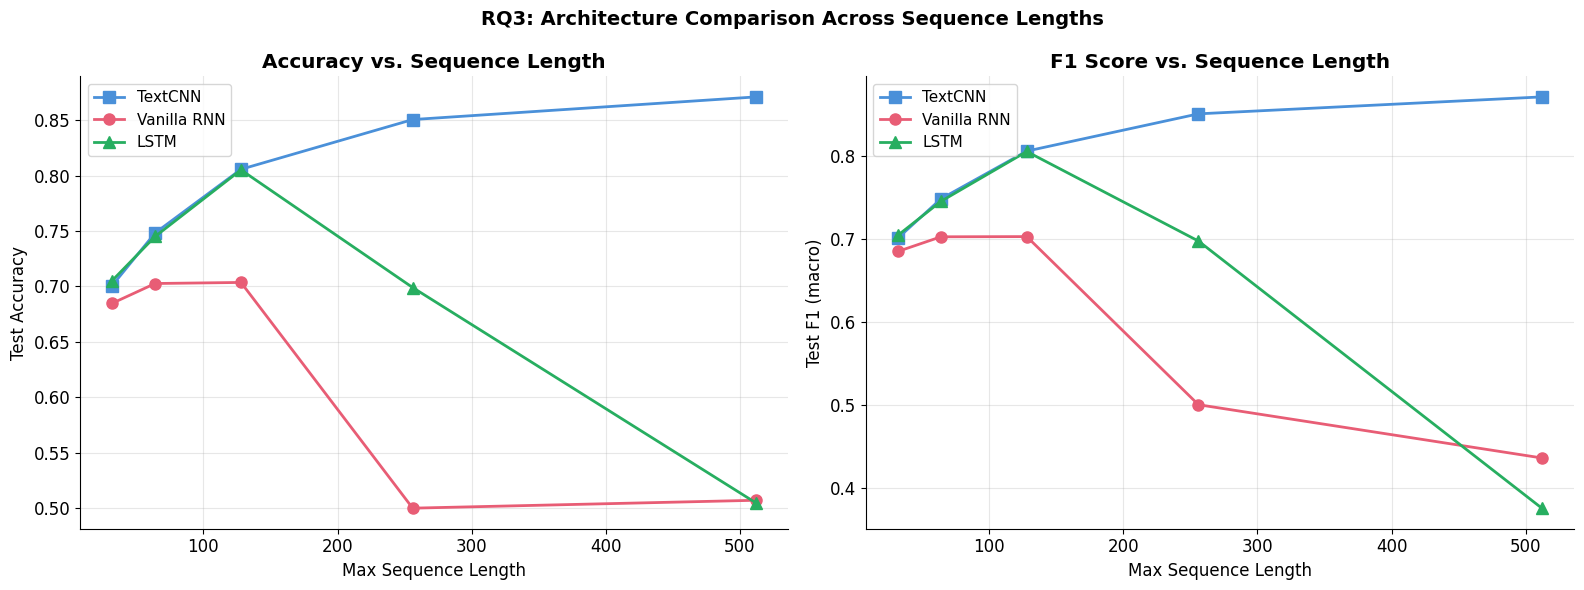

In [13]:
# ── Performance curves ─────────────────────────────────────────
model_names = list(get_models().keys())
colors = {'TextCNN': '#4A90D9', 'Vanilla RNN': '#E85D75',
          'LSTM': '#27AE60', 'MLP': '#64748B'}
markers = {'TextCNN': 's', 'Vanilla RNN': 'o', 'LSTM': '^', 'MLP': 'D'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name in model_names:
    accs = [results[(name, sl)]['accuracy'] for sl in SEQ_LENGTHS]
    f1s = [results[(name, sl)]['f1'] for sl in SEQ_LENGTHS]

    ax1.plot(SEQ_LENGTHS, accs, f'{markers.get(name, "o")}-',
             color=colors.get(name, '#333'), linewidth=2, markersize=8, label=name)
    ax2.plot(SEQ_LENGTHS, f1s, f'{markers.get(name, "o")}-',
             color=colors.get(name, '#333'), linewidth=2, markersize=8, label=name)

ax1.set_xlabel("Max Sequence Length")
ax1.set_ylabel("Test Accuracy")
ax1.set_title("Accuracy vs. Sequence Length", fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Max Sequence Length")
ax2.set_ylabel("Test F1 (macro)")
ax2.set_title("F1 Score vs. Sequence Length", fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle("RQ3: Architecture Comparison Across Sequence Lengths",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# TODO: Interpret this plot in your report. Key questions:
# - At which sequence length does the vanilla RNN start to degrade?
# - Does the LSTM maintain performance at longer sequences?
# - When does TextCNN perform comparably to or better than the recurrent models?

### 5.2 Results Table

In [14]:
# ── Results table ──────────────────────────────────────────────
print(f"{'Architecture':<15}", end="")
for sl in SEQ_LENGTHS:
    print(f"  Len={sl:<4}", end="")
print()
print("-" * (15 + 10 * len(SEQ_LENGTHS)))

for name in model_names:
    print(f"{name:<15}", end="")
    for sl in SEQ_LENGTHS:
        acc = results[(name, sl)]['accuracy']
        print(f"  {acc:.4f}  ", end="")
    print()

# TODO: Include this table in your report (Methods or Results section)

Architecture     Len=32    Len=64    Len=128   Len=256   Len=512 
-----------------------------------------------------------------
TextCNN          0.7009    0.7483    0.8057    0.8506    0.8710  
Vanilla RNN      0.6848    0.7027    0.7036    0.5000    0.5071  
LSTM             0.7054    0.7451    0.8052    0.6990    0.5047  


### 5.3 Training Speed Comparison

Sequential architectures (RNN, LSTM) process tokens one at a time — they cannot parallelize across the sequence. This section measures that cost.

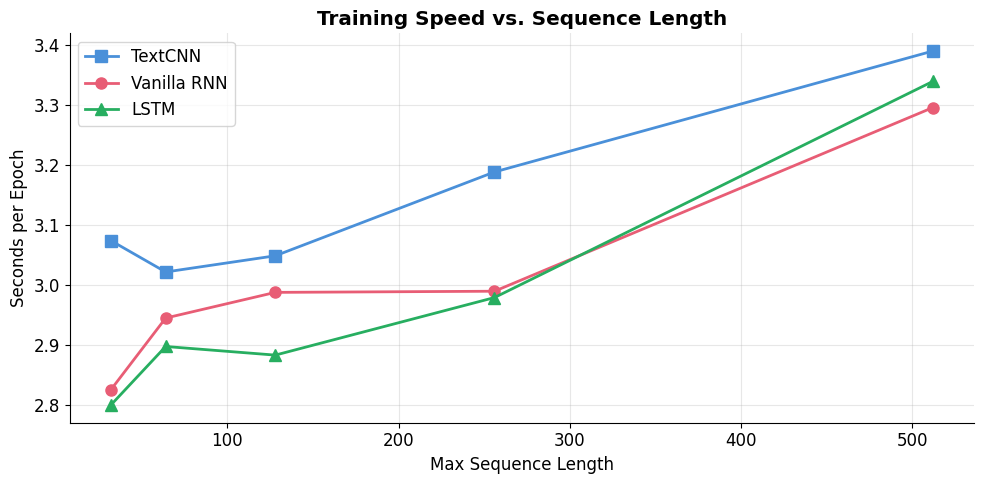

In [15]:
# ── Training time comparison ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for name in model_names:
    times = [results[(name, sl)]['time_per_epoch'] for sl in SEQ_LENGTHS]
    ax.plot(SEQ_LENGTHS, times, f'{markers.get(name, "o")}-',
            color=colors.get(name, '#333'), linewidth=2, markersize=8, label=name)

ax.set_xlabel("Max Sequence Length")
ax.set_ylabel("Seconds per Epoch")
ax.set_title("Training Speed vs. Sequence Length", fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# TODO: Does the RNN/LSTM become slower at longer sequences? Why?
# (Hint: sequential processing scales linearly with sequence length,
#  while CNN processes all positions in parallel)

---
## Part 6: Error Analysis

Pick one sequence length (e.g., 256) and compare what the models get right and wrong.

`# TODO`: This is the most important analytical section. Show concrete examples and explain *why* each model succeeds or fails.

In [16]:
# ── Error analysis at a chosen sequence length ────────────────
ANALYSIS_SEQ_LEN = 256  # TODO: choose the most interesting length

# Get predictions for each model at this length
analysis_preds = {}
for name in model_names:
    analysis_preds[name] = np.array(results[(name, ANALYSIS_SEQ_LEN)]['predictions'])

true_labels = np.array(results[(model_names[0], ANALYSIS_SEQ_LEN)]['labels'])
label_names = {0: "Negative", 1: "Positive"}

# Find disagreements
print(f"Error analysis at seq_len={ANALYSIS_SEQ_LEN}")
print(f"{'='*60}")

for m1, m2 in [('LSTM', 'Vanilla RNN'), ('LSTM', 'TextCNN'), ('TextCNN', 'Vanilla RNN')]:
    if m1 in analysis_preds and m2 in analysis_preds:
        m1_correct = analysis_preds[m1] == true_labels
        m2_correct = analysis_preds[m2] == true_labels
        m1_wins = m1_correct & ~m2_correct
        m2_wins = m2_correct & ~m1_correct

        print(f"\n{m1} wins over {m2}: {m1_wins.sum()} examples")
        print(f"{m2} wins over {m1}: {m2_wins.sum()} examples")

Error analysis at seq_len=256

LSTM wins over Vanilla RNN: 8780 examples
Vanilla RNN wins over LSTM: 3804 examples

LSTM wins over TextCNN: 1903 examples
TextCNN wins over LSTM: 5692 examples

TextCNN wins over Vanilla RNN: 10684 examples
Vanilla RNN wins over TextCNN: 1919 examples


In [17]:
# ── Show concrete examples ─────────────────────────────────────
# TODO: Examine these examples and explain WHY each model
#       gets them right or wrong. This is the core of your discussion.

def show_examples(category_name, indices, n=5):
    print(f"\n{'='*60}")
    print(f"{category_name}")
    print(f"{'='*60}")
    for idx in indices[:n]:
        if idx < len(test_texts):
            text_preview = test_texts[idx][:200] + "..."
            print(f"\nTrue: {label_names[true_labels[idx]]}")
            for name in model_names:
                pred = analysis_preds[name][idx]
                correct = "✓" if pred == true_labels[idx] else "✗"
                print(f"  {name}: {label_names[pred]} {correct}")
            print(f"  Text: {text_preview}")

# LSTM wins over Vanilla RNN (long-range dependencies)
if 'LSTM' in analysis_preds and 'Vanilla RNN' in analysis_preds:
    lstm_wins = np.where(
        (analysis_preds['LSTM'] == true_labels) &
        (analysis_preds['Vanilla RNN'] != true_labels)
    )[0]
    show_examples("LSTM correct, Vanilla RNN wrong (long-range memory helps)", lstm_wins)

# TextCNN wins (local patterns sufficient)
if 'TextCNN' in analysis_preds and 'LSTM' in analysis_preds:
    cnn_wins = np.where(
        (analysis_preds['TextCNN'] == true_labels) &
        (analysis_preds['LSTM'] != true_labels)
    )[0]
    show_examples("TextCNN correct, LSTM wrong (local patterns sufficient)", cnn_wins)

# All wrong (hard examples)
all_wrong = np.ones(len(true_labels), dtype=bool)
for name in model_names:
    all_wrong &= (analysis_preds[name] != true_labels)
show_examples("All models wrong (hard examples — what would we need?)", np.where(all_wrong)[0])


LSTM correct, Vanilla RNN wrong (long-range memory helps)

True: Negative
  TextCNN: Negative ✓
  Vanilla RNN: Positive ✗
  LSTM: Negative ✓
  Text: its a totally average film with a few semi-alright action sequences that make the plot seem a little better and remind the viewer of the classic van dam films. parts of the plot don't make sense and s...

True: Negative
  TextCNN: Negative ✓
  Vanilla RNN: Positive ✗
  LSTM: Negative ✓
  Text: STAR RATING: ***** Saturday Night **** Friday Night *** Friday Morning ** Sunday Night * Monday Morning <br /><br />Former New Orleans homicide cop Jack Robideaux (Jean Claude Van Damme) is re-assigne...

True: Negative
  TextCNN: Positive ✗
  Vanilla RNN: Positive ✗
  LSTM: Negative ✓
  Text: First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy thes...

True: Negative
  TextCNN: Negative ✓
  Vanilla RNN: Pos

### 6.1 Confusion Matrices

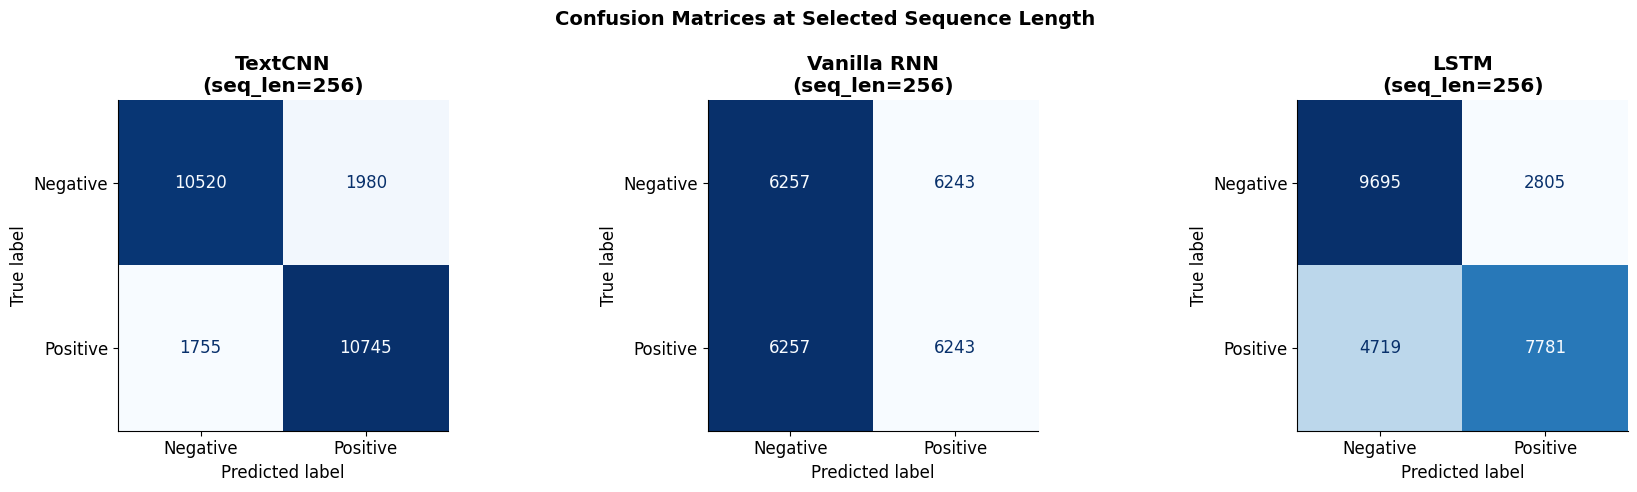

In [18]:
# ── Confusion matrices ─────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(model_names), figsize=(6 * len(model_names), 5))
if len(model_names) == 1:
    axes = [axes]

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(true_labels, analysis_preds[name])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{name}\n(seq_len={ANALYSIS_SEQ_LEN})", fontweight='bold')

plt.suptitle("Confusion Matrices at Selected Sequence Length",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## Part 7: Your Analysis

`# TODO`: Add your own analysis cells below. Consider:

1. **Content vs. architecture:** At short sequence lengths, accuracy drops for all models. How much of this is due to missing content (truncated reviews) vs. architectural limitations? Use the review length statistics from Part 1 to support your argument.
2. **The key signal:** Does any model's accuracy *drop or plateau* at longer lengths while another model *improves*? If so, this is pure architectural evidence — more content is available but one architecture cannot exploit it.
3. **Does TextCNN performance plateau** at longer sequences (since it only uses local patterns)?
4. **Training speed vs. accuracy trade-off:** Is the LSTM's extra training cost justified by its accuracy gain?
5. **Practical recommendation:** Based on your results, which architecture would you recommend for a production sentiment system? Consider accuracy, training speed, and robustness to input length.

Add code cells, visualizations, and markdown commentary as needed.

In [19]:
# TODO: Your additional analysis here
# Ideas:
# - Plot accuracy difference (LSTM - Vanilla RNN) vs. sequence length
# - Analyze average review length and its correlation with performance
# - Compare parameter counts across models


---
## Part 8: Further Exploration (Optional)

These quick experiments deepen your understanding — each requires only 1–2 extra training runs. They are not required but can strengthen your discussion.

In [20]:
# ── Does a larger vanilla RNN fix the long-sequence problem? ──
# Train a vanilla RNN with hidden_dim=256 or 512 at your longest sequence length.
# If it still degrades compared to LSTM, the problem is architectural
# (vanishing gradients), not a capacity issue.

# TODO: Try VanillaRNNClassifier with hidden_dim=256 and hidden_dim=512
# Compare with the standard hidden_dim=128 LSTM at the same sequence length.


In [21]:
# ── Parameter counts: how big is each model actually? ──
for name, model in get_models().items():
    total = sum(p.numel() for p in model.parameters())
    embed = model.embedding.weight.numel()
    print(f"{name:15s}  Total: {total:>10,}  (excl. embedding: {total - embed:>8,})")

TextCNN          Total:  2,120,902  (excl. embedding:  120,902)
Vanilla RNN      Total:  2,029,698  (excl. embedding:   29,698)
LSTM             Total:  2,118,018  (excl. embedding:  118,018)


In [22]:
# ── Does a wider receptive field help TextCNN? ──
# TODO: Train a TextCNN with filter_sizes=(5, 7, 9) instead of (3, 4, 5)
# at seq_len=512. Does a wider window compensate for the lack of memory?


---
## Summary

Fill in your key findings:

| Finding | Evidence |
|---------|----------|
| TextCNN performs best at seq_len = ? | [your result] |
| Vanilla RNN starts degrading at seq_len = ? | [your result] |
| LSTM advantage becomes clear at seq_len = ? | [your result] |
| Training speed difference at seq_len=512 | [your result] |
| Content incompleteness effect at seq_len=32 | [your analysis] |

### Practical Recommendation

*[Based on your results: which architecture would you recommend for a production sentiment classification system, and why? Consider accuracy, training speed, and robustness to varying input lengths.]*

### Key Takeaway

*[Write 2-3 sentences summarizing what you learned from this comparison. Connect it to the lecture content about vanishing gradients and the motivation for attention/Transformers.]*